Phase 1: Data Understanding

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-muted') # Or 'ggplot' for a classic look

In [3]:
matches = pd.read_csv("matches.csv")
deliveries= pd.read_csv("deliveries.csv")
batting = pd.read_csv("batting_stats.csv")
bowling = pd.read_csv("bowling_stats.csv")

In [4]:
matches.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No
2,3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,...,RR,NaN,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.0,Jofra Archer,2--19,No
3,4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,...,PBKS,NaN,3.0,5.0,Cooper Connolly,Cooper Connolly,72.0,Prasidh Krishna,3--29,No
4,5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,...,DC,NaN,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.0,Lungi Ngidi,3--27,No


In [5]:
deliveries.head()

,match_no,date,stage,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder
0,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
1,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN
2,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN
3,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN
4,1,"Mar 28, 2026",League stage,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN


In [6]:
matches.info()
deliveries.info()

matches.shape
deliveries.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             39 non-null     int64  
 1   date                 39 non-null     object 
 2   venue                39 non-null     object 
 3   team1                39 non-null     object 
 4   team2                39 non-null     object 
 5   stage                39 non-null     object 
 6   toss_winner          39 non-null     object 
 7   toss_decision        39 non-null     object 
 8   first_ings_score     38 non-null     float64
 9   first_ings_wkts      38 non-null     float64
 10  second_ings_score    38 non-null     float64
 11  second_ings_wkts     38 non-null     float64
 12  match_result         39 non-null     object 
 13  match_winner         38 non-null     object 
 14  wb_runs              15 non-null     float64
 15  wb_wickets           22 non-null     float

(17477, 19)

In [7]:
matches.isnull().sum()
deliveries.isnull().sum()

match_no                0
date                    0
stage                   0
venue                   0
batting_team            0
bowling_team            0
innings                 0
over                    0
striker                 0
bowler                  0
runs_of_bat             0
extras                  0
wide                    0
legbyes                 0
byes                    0
noballs                 0
wicket_type         16598
player_dismissed    16602
fielder             16791
dtype: int64

In [9]:
pd.concat([ 
    matches['team1'],
    matches['team2']
]).unique()

array(['RCB', 'MI', 'RR', 'PBKS', 'LSG', 'KKR', 'CSK', 'DC', 'GT', 'SRH'],
      dtype=object)

Phase 2: Match Analysis

In [10]:
team_matches = pd.concat([ 
    matches['team1'],
    matches['team2']
]).value_counts()

In [11]:
team_matches

RCB     8
RR      8
GT      8
LSG     8
KKR     8
CSK     8
SRH     8
DC      8
MI      7
PBKS    7
Name: count, dtype: int64

Text(0, 0.5, 'Count')

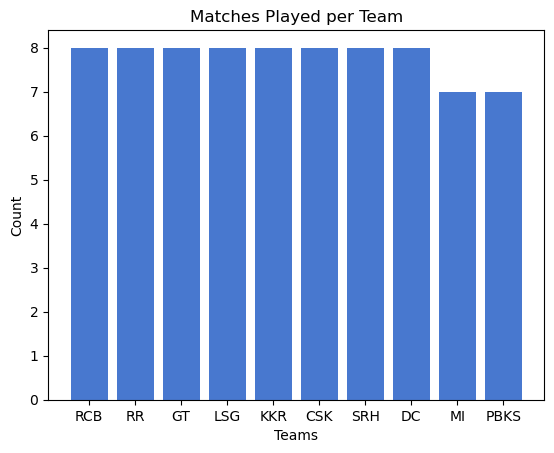

In [64]:
plt.bar(team_matches.index, team_matches.values)
plt.title('Matches Played per Team')
plt.xlabel('Teams')
plt.ylabel('Count')

In [16]:
matches.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No
2,3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,...,RR,NaN,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.0,Jofra Archer,2--19,No
3,4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,...,PBKS,NaN,3.0,5.0,Cooper Connolly,Cooper Connolly,72.0,Prasidh Krishna,3--29,No
4,5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,...,DC,NaN,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.0,Lungi Ngidi,3--27,No


In [17]:
wins = matches['match_winner'].value_counts()

In [18]:
wins

match_winner
RCB     6
PBKS    6
SRH     5
RR      4
GT      4
DC      3
CSK     3
LSG     3
MI      2
KKR     2
Name: count, dtype: int64

Text(0, 0.5, 'Wins')

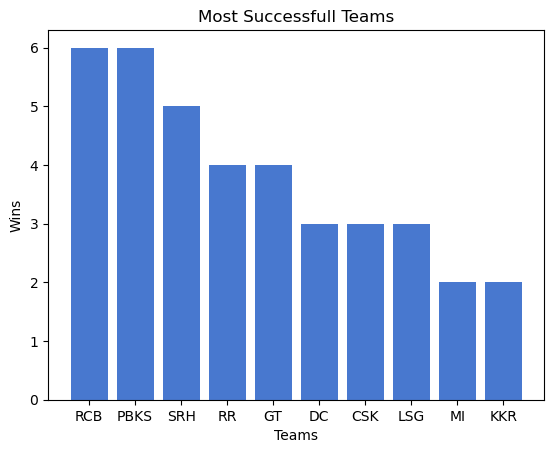

In [65]:
plt.bar(wins.index, wins.values)
plt.title('Most Successfull Teams')
plt.xlabel('Teams')
plt.ylabel('Wins')

Phase 3: Batting Analysis

In [23]:
batting.head()

,position,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
0,1,Abhishek Sharma,SRH,8,8,380,395.6,54.28,212.29,1,135,179,1,3,2,36,28
1,2,KL Rahul,DC,8,8,358,317.6,51.14,185.49,1,152,193,1,2,1,36,19
2,3,Vaibhav Sooryavanshi,RR,8,8,357,433.2,44.62,234.86,0,103,152,1,2,1,31,32
3,4,Virat Kohli,RCB,8,8,351,282.2,58.50,162.50,2,81,216,0,3,0,37,14
4,5,Heinrich Klaasen,SRH,8,8,349,258.6,49.85,149.78,1,62,233,0,3,0,25,14


In [27]:
top_batsmen = batting.sort_values('runs', ascending=False)

In [28]:
top_batsmen.head()

,position,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
0,1,Abhishek Sharma,SRH,8,8,380,395.6,54.28,212.29,1,135,179,1,3,2,36,28
1,2,KL Rahul,DC,8,8,358,317.6,51.14,185.49,1,152,193,1,2,1,36,19
2,3,Vaibhav Sooryavanshi,RR,8,8,357,433.2,44.62,234.86,0,103,152,1,2,1,31,32
3,4,Virat Kohli,RCB,8,8,351,282.2,58.50,162.50,2,81,216,0,3,0,37,14
4,5,Heinrich Klaasen,SRH,8,8,349,258.6,49.85,149.78,1,62,233,0,3,0,25,14


Text(0.5, 1.0, 'Top Run Scorers')

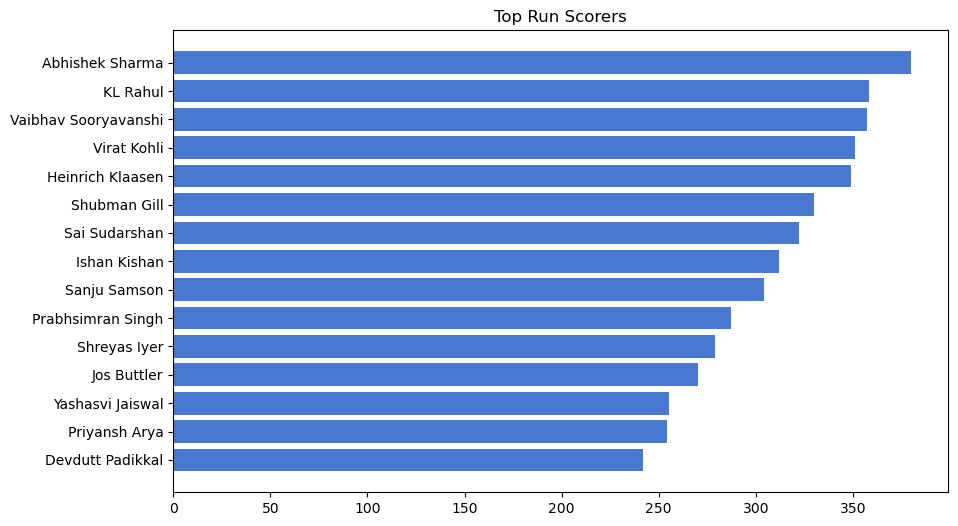

In [66]:
plt.figure(figsize=(10,6))
plt.barh(top_batsmen['batsman'],top_batsmen['runs'])
plt.gca().invert_yaxis()
plt.title("Top Run Scorers")

In [40]:
Best_Strike_Rate = batting.sort_values('strike_rate', ascending=False).head()

In [41]:
Best_Strike_Rate

,position,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
13,14,Priyansh Arya,PBKS,6,6,254,363.7,42.33,249.01,0,93,102,0,2,0,16,25
2,3,Vaibhav Sooryavanshi,RR,8,8,357,433.2,44.62,234.86,0,103,152,1,2,1,31,32
0,1,Abhishek Sharma,SRH,8,8,380,395.6,54.28,212.29,1,135,179,1,3,2,36,28
7,8,Ishan Kishan,SRH,8,8,312,381.7,39.00,198.72,0,91,157,0,3,1,35,16
9,10,Prabhsimran Singh,PBKS,7,6,287,318.8,57.40,192.61,1,80,149,0,3,1,31,16


Text(0.5, 1.0, 'Best Strike Rates')

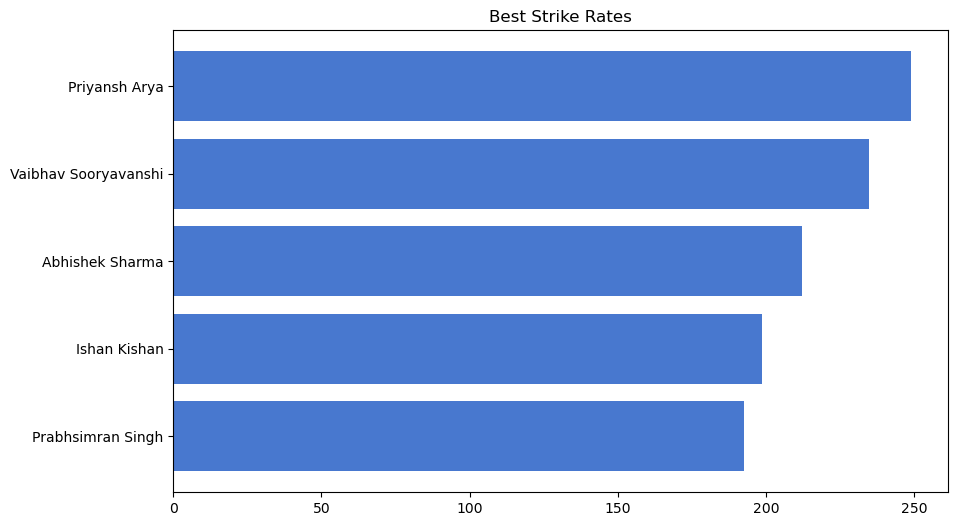

In [67]:
plt.figure(figsize=(10,6))
plt.barh(Best_Strike_Rate['batsman'],Best_Strike_Rate['strike_rate'])
plt.gca().invert_yaxis()
plt.title("Best Strike Rates")

Text(0.5, 1.0, 'Best Strike Rates')

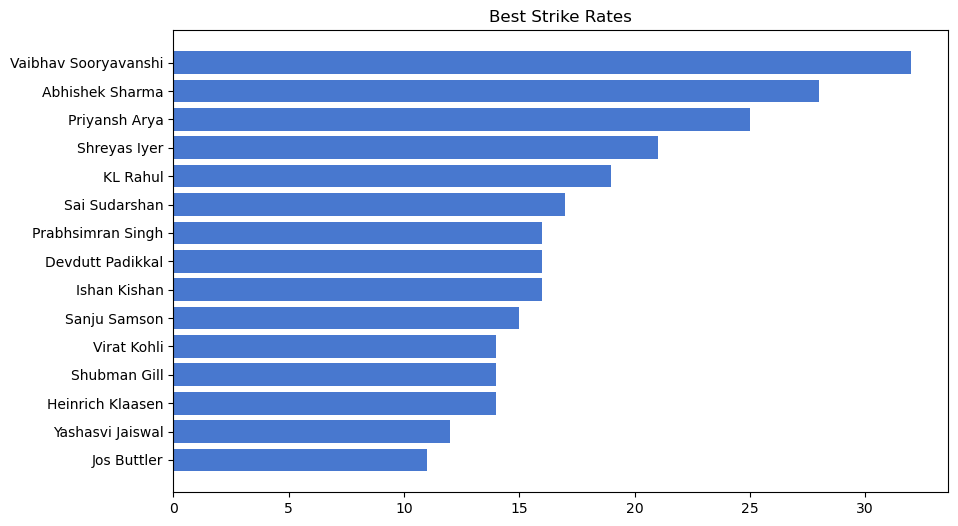

In [68]:
Most_sixes = batting.sort_values('sixes', ascending=False)
plt.figure(figsize=(10,6))
plt.barh(Most_sixes['batsman'],Most_sixes['sixes'])
plt.gca().invert_yaxis()
plt.title("Best Strike Rates")

Text(0.5, 1.0, 'Best Strike Rates')

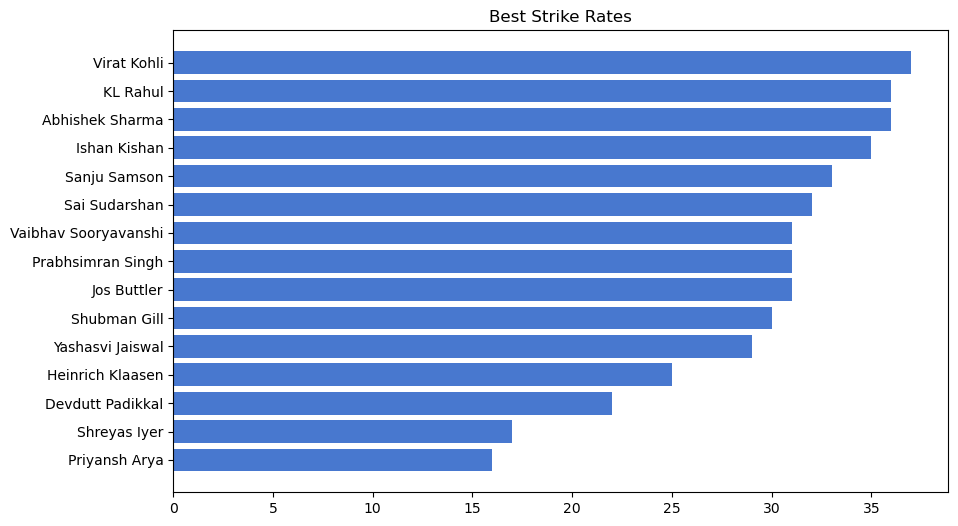

In [69]:
Most_fours = batting.sort_values('fours', ascending=False)
plt.figure(figsize=(10,6))
plt.barh(Most_fours['batsman'],Most_fours['fours'])
plt.gca().invert_yaxis()
plt.title("Best Strike Rates")

In [45]:
Orange_cap = batting.nlargest(10, 'runs')

In [46]:
Orange_cap

,position,batsman,team,matches,innings,runs,impact,average,strike_rate,not_outs,high_score,balls_faced,hundreds,fifties,ducks,fours,sixes
0,1,Abhishek Sharma,SRH,8,8,380,395.6,54.28,212.29,1,135,179,1,3,2,36,28
1,2,KL Rahul,DC,8,8,358,317.6,51.14,185.49,1,152,193,1,2,1,36,19
2,3,Vaibhav Sooryavanshi,RR,8,8,357,433.2,44.62,234.86,0,103,152,1,2,1,31,32
3,4,Virat Kohli,RCB,8,8,351,282.2,58.50,162.50,2,81,216,0,3,0,37,14
4,5,Heinrich Klaasen,SRH,8,8,349,258.6,49.85,149.78,1,62,233,0,3,0,25,14
5,6,Shubman Gill,GT,7,7,330,279.1,47.14,148.64,0,86,222,0,3,0,30,14
6,7,Sai Sudarshan,GT,8,8,322,274.4,40.25,163.45,0,100,197,1,2,1,32,17
7,8,Ishan Kishan,SRH,8,8,312,381.7,39.00,198.72,0,91,157,0,3,1,35,16
8,9,Sanju Samson,CSK,8,8,304,369.4,50.66,169.83,2,115,179,2,0,0,33,15
9,10,Prabhsimran Singh,PBKS,7,6,287,318.8,57.40,192.61,1,80,149,0,3,1,31,16


Phase 4: Bowling Analysis

In [48]:
bowling.head()

,position,bowler,team,matches,innings,wickets,economy,impact,bbi,overs,balls,dot_balls,maiden_overs,runs,avg,4wh,5wh
0,1,Bhuvneshwar Kumar,RCB,8,8,14,7.61,351.0,3--5,31.0,186,72,0,236,16.85,0,0
1,2,Anshul Kamboj,CSK,8,8,14,8.56,284.8,3--22,27.4,166,75,0,237,16.92,0,0
2,3,Eshan Malinga,SRH,8,8,14,9.44,293.1,4--32,27.0,162,61,0,255,18.21,1,0
3,4,Jofra Archer,RR,8,8,13,8.03,343.0,3--20,29.0,174,88,1,233,17.92,0,0
4,5,Prince Yadav,LSG,8,8,13,8.06,355.8,3--32,30.0,180,77,0,242,18.61,0,0


Text(0.5, 1.0, 'Top Bowler by wickets')

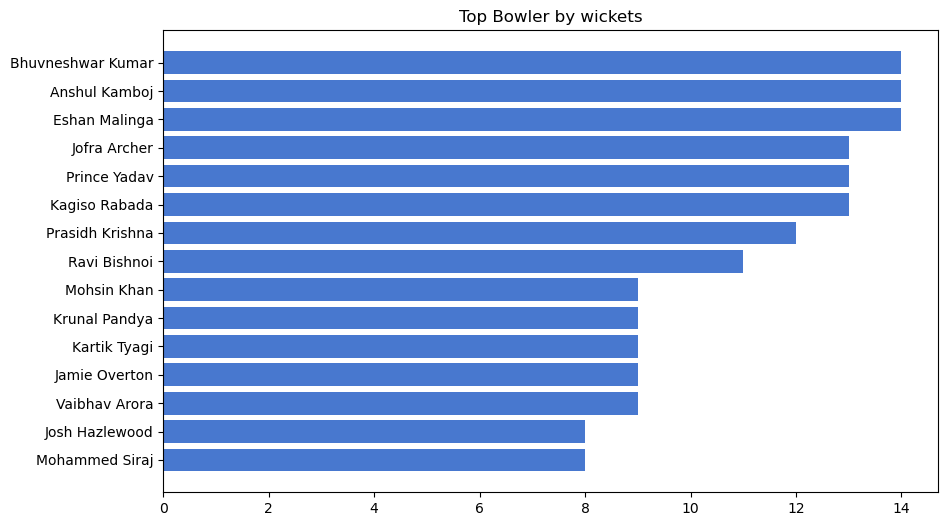

In [70]:
top_bowler = bowling.sort_values('wickets', ascending=False)
plt.figure(figsize=(10,6))
plt.barh(top_bowler['bowler'],top_bowler['wickets'])
plt.gca().invert_yaxis()
plt.title("Top Bowler by wickets")

Text(0.5, 1.0, 'Top Bowler by economy')

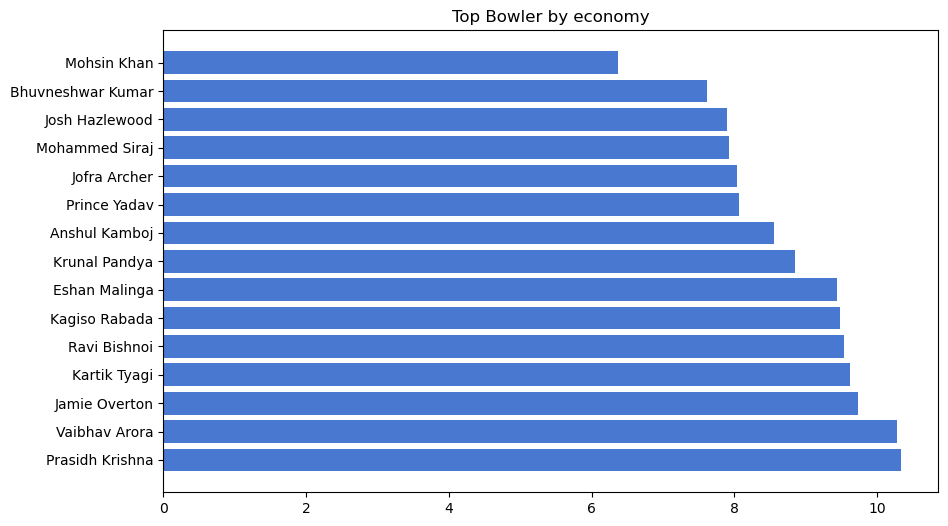

In [71]:
best_economy = bowling.sort_values('economy')
plt.figure(figsize=(10,6))
plt.barh(best_economy['bowler'],best_economy['economy'])
plt.gca().invert_yaxis()
plt.title("Top Bowler by economy")

Text(0.5, 1.0, 'Top Bowler by dot balls')

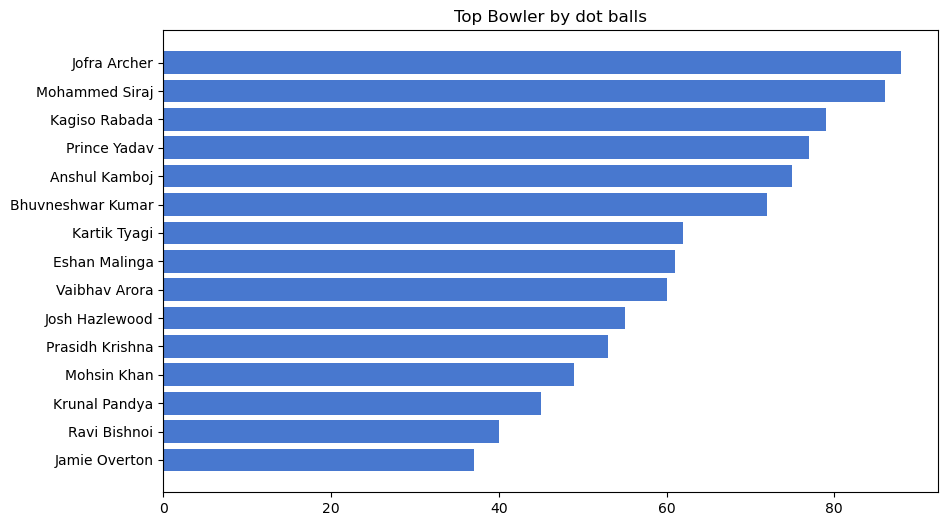

In [72]:
best_dot_ball = bowling.sort_values('dot_balls', ascending=False)
plt.figure(figsize=(10,6))
plt.barh(best_dot_ball['bowler'],best_dot_ball['dot_balls'])
plt.gca().invert_yaxis()
plt.title("Top Bowler by dot balls")

Phase 5: Venue Analysis

In [57]:
matches.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No
2,3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,...,RR,NaN,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.0,Jofra Archer,2--19,No
3,4,"March 31, 2026","New PCA Cricket Stadium, Mullanpur",PBKS,GT,League,PBKS,Bowl,162.0,6.0,...,PBKS,NaN,3.0,5.0,Cooper Connolly,Cooper Connolly,72.0,Prasidh Krishna,3--29,No
4,5,"April 01, 2026","Ekana Cricket Stadium, Lucknow",LSG,DC,League,DC,Bowl,141.0,10.0,...,DC,NaN,6.0,17.0,Sameer Rizvi,Sameer Rizvi,70.0,Lungi Ngidi,3--27,No


In [59]:
venue_runs = matches.groupby('venue')['first_ings_score'].mean().sort_values(ascending=False)

In [60]:
venue_runs.head()

venue
Sawai Mansingh Stadium, Jaipur                   228.000000
Wankhede Stadium, Mumbai                         215.500000
New PCA Cricket Stadium, Mullanpur               211.666667
MA Chidambaram Stadium, Chennai                  204.333333
Rajiv Gandhi International Stadium, Hyderabad    202.000000
Name: first_ings_score, dtype: float64

Text(0.5, 1.0, 'Average First Innings Score by Venue')

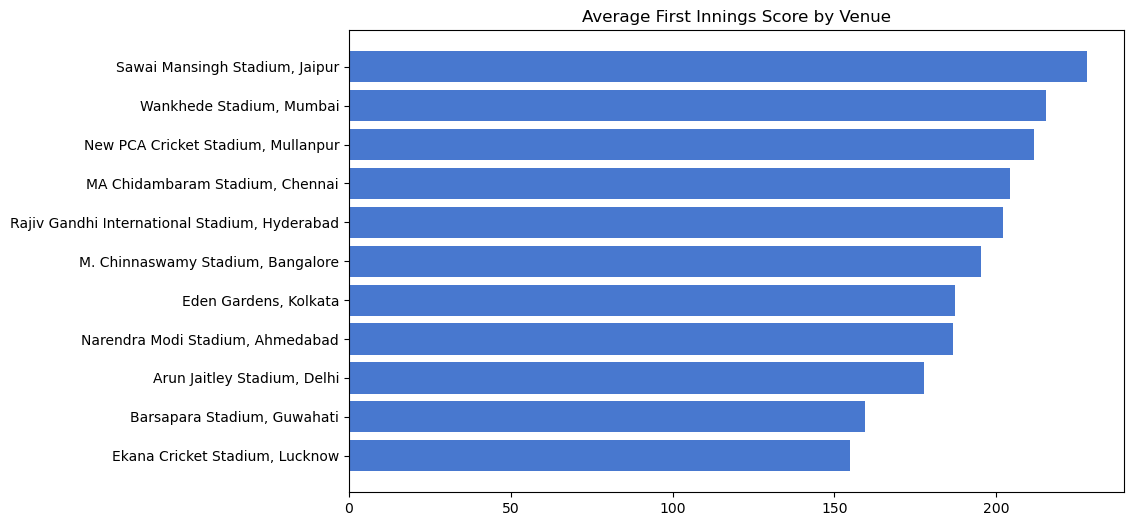

In [73]:
plt.figure(figsize=(10,6))
plt.barh(venue_runs.index,venue_runs.values)
plt.gca().invert_yaxis()
plt.title("Average First Innings Score by Venue")